In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
ds1 = pd.read_csv('paises (2).csv',sep = ';')
ds2 = pd.read_csv('space.csv',sep = ';')
print(ds1.columns) # visualizando as colunas
print("-----------------------------------------------------")
print(ds2.columns) # visualizando as colunas

print(ds1['Region'])


Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')
-----------------------------------------------------
Index(['Num', 'Company Name', 'Location', 'Datum', 'Detail', 'Status Rocket',
       ' Cost', 'Status Mission'],
      dtype='object')
0            ASIA (EX. NEAR EAST)         
1      EASTERN EUROPE                     
2      NORTHERN AFRICA                    
3      OCEANIA                            
4      WESTERN EUROPE                     
                      ...                 
222    NEAR EAST                          
223    NORTHERN AFRICA                    
224    NEAR EAST                          
225    SUB-SAHA

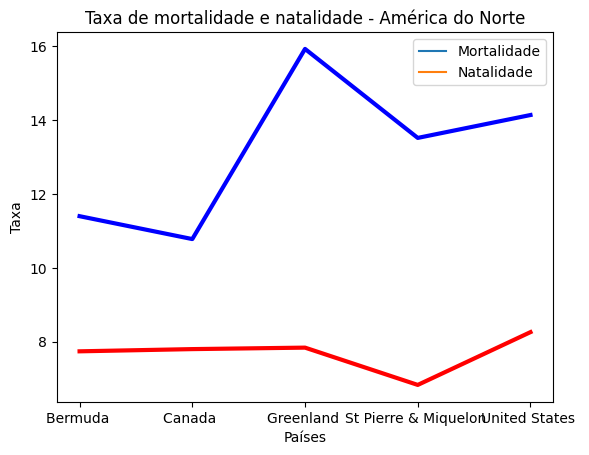

In [8]:
cond = ds1['Region'].str.strip() == 'NORTHERN AMERICA'

paises = ds1[cond]['Country']
deathrate = ds1[cond]['Deathrate']
birthrate = ds1[cond]['Birthrate']

plt.plot(paises, deathrate)
plt.plot(paises, birthrate)

plt.plot(paises, deathrate, 'r-', linewidth=3)
plt.plot(paises, birthrate, 'b-', linewidth=3)

plt.xlabel('Países')
plt.ylabel('Taxa')
plt.title('Taxa de mortalidade e natalidade - América do Norte')
plt.legend(['Mortalidade', 'Natalidade'])

plt.show()

0         SpaceX
2         SpaceX
4            ULA
8         SpaceX
10      Northrop
          ...   
4317     US Navy
4318        AMBA
4319     US Navy
4320        AMBA
4321     US Navy
Name: Company Name, Length: 1344, dtype: object
1         CASC
5         CASC
7         CASC
11      ExPace
12        CASC
         ...  
3110      CASC
3215      CASC
3375      CASC
3471      CASC
3509      CASC
Name: Company Name, Length: 268, dtype: object
Empresas diferentes nos EUA: 16
Empresas diferentes na China: 6


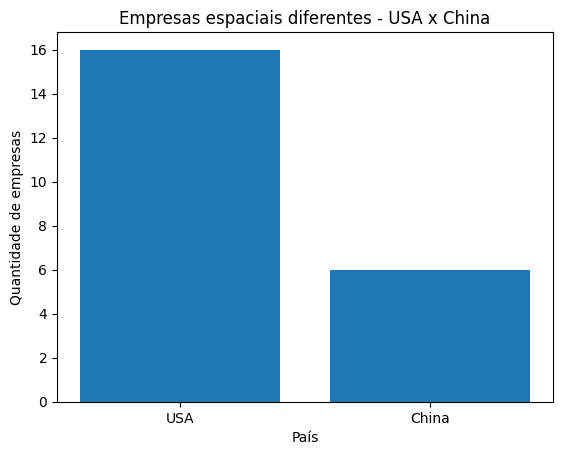

In [24]:
usa = ds2['Location'].str.endswith('USA')
china = ds2['Location'].str.endswith('China')

empresas_usa = ds2[usa]['Company Name']
print(empresas_usa)
empresas_china = ds2[china]['Company Name']
print(empresas_china)

nomes_usa,quant_usa = np.unique(empresas_usa, return_counts = True)
nomes_china, quant_china = np.unique(empresas_china, return_counts = True)


qtd_usa = len(nomes_usa)
qtd_china = len(nomes_china)

print('Empresas diferentes nos EUA:', qtd_usa)
print('Empresas diferentes na China:', qtd_china)


paises = ['USA', 'CHINA']
quantidades = [qtd_usa, qtd_china]
plt.bar(paises, quantidades)

plt.xlabel('País')
plt.ylabel('Quantidade de empresas')
plt.title('Empresas espaciais diferentes - USA x China')

plt.show()


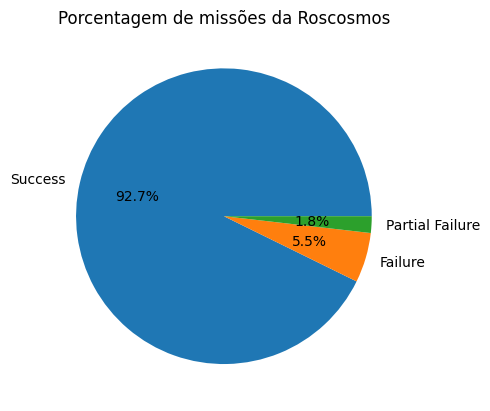

In [27]:
cond = ds2['Company Name'] == 'Roscosmos'
roscosmos = ds2[cond] # aqui vai pegar a informações de todas as colunas do dataset mas sendo da empresa roscosmos

status_roscosmos = roscosmos['Status Mission'].value_counts()

plt.pie(
    status_roscosmos.values,
    labels=status_roscosmos.index,
    autopct='%1.1f%%'
)

plt.title('Porcentagem de missões da Roscosmos')

plt.show()

Company Name
RVSN USSR           121
General Dynamics     37
US Air Force         30
US Navy              14
CASC                 14
Name: count, dtype: int64


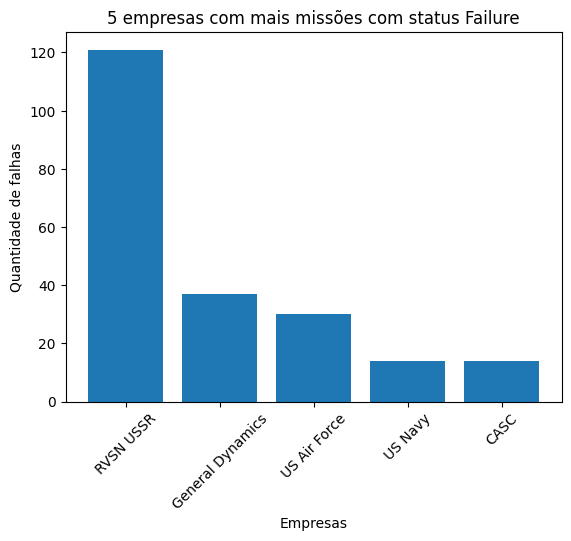

In [29]:
cond = ds2['Status Mission'] == 'Failure'
failure = ds2[cond]

empresas_failure = failure['Company Name'].value_counts()

top5 = empresas_failure.head(5)

plt.bar(top5.index, top5.values)

plt.xlabel('Empresas')
plt.ylabel('Quantidade de falhas')
plt.title('5 empresas com mais missões com status Failure')

plt.xticks(rotation=45)

plt.show()